# Slow Dynamics and High Variability in Networks with Clustered Connections




In [2]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from model import ClusterParams, ModelParams, NeuronNetwork, firing_rate

# Run and plot an un-clustered network

In [3]:
params = ModelParams()
cluster_params = ClusterParams(enabled=False, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

In [ ]:
def plot_spike_raster(spike_monitor_e, spike_monitor_i=None, n_e=0, title="Spike raster", ax=None):
    """Plot a spike raster for excitatory (and optionally inhibitory) neurons.
    
    Args:
        spike_monitor_e: Brian2 SpikeMonitor for excitatory neurons
        spike_monitor_i: Brian2 SpikeMonitor for inhibitory neurons (optional)
        n_e: Number of excitatory neurons (used to offset inhibitory neuron indices)
        title: Plot title
        ax: Matplotlib axes to plot on. If None, creates a new figure.
    
    Returns:
        The axes object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))
    
    ax.plot(spike_monitor_e.t / ms, spike_monitor_e.i, ".", markersize=2, label="E")
    if spike_monitor_i is not None:
        ax.plot(
            spike_monitor_i.t / ms,
            spike_monitor_i.i + n_e,
            ".",
            markersize=2,
            label="I",
        )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Neuron index")
    ax.set_title(title)
    ax.legend(loc="upper right")
    
    return ax


def plot_trial_rasters(network, n_trials=9, ncols=3, figsize=None, show_inhibitory=False):
    """Plot spike rasters for multiple trials of a network in a grid"""
    nrows = int(np.ceil(n_trials / ncols))
    
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = np.atleast_2d(axes)  # Ensure 2D array even if nrows=1
    
    for trial in range(n_trials):
        row = trial // ncols
        col = trial % ncols
        ax = axes[row, col]
        
        network.run()
        
        spike_monitor_i = network.spike_monitor_i if show_inhibitory else None
        n_e = network.params.N_E if show_inhibitory else 0
        
        plot_spike_raster(
            network.spike_monitor_e,
            spike_monitor_i,
            n_e=n_e,
            title=f"Trial {trial + 1}",
            ax=ax
        )
        
        # Only show legend on first plot to reduce clutter
        if trial > 0:
            ax.get_legend().remove()
    
    # Hide any unused subplots
    for idx in range(n_trials, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    return fig, axes

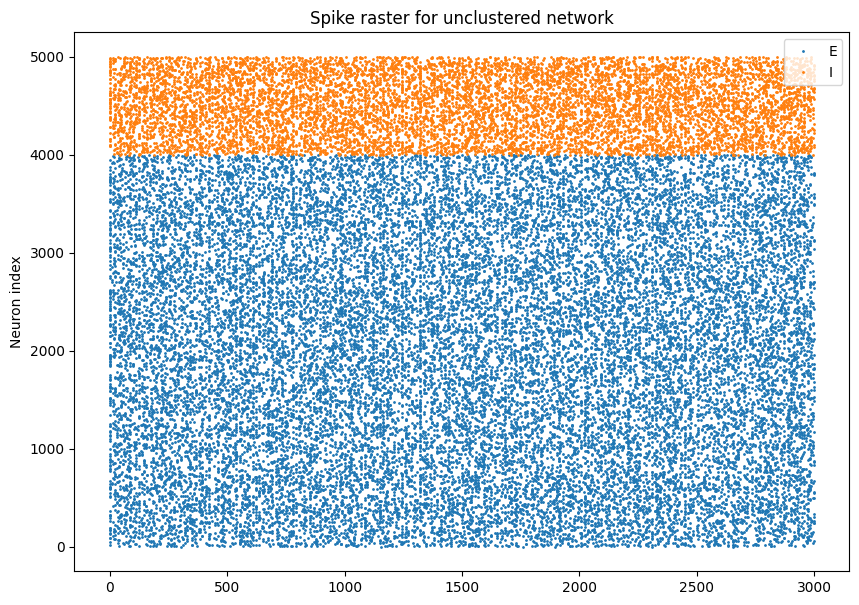

In [5]:
# Single raster plot
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    unclustered_network.spike_monitor_i,
    n_e=params.N_E,
    title="Spike raster for unclustered network",
)
plt.show()

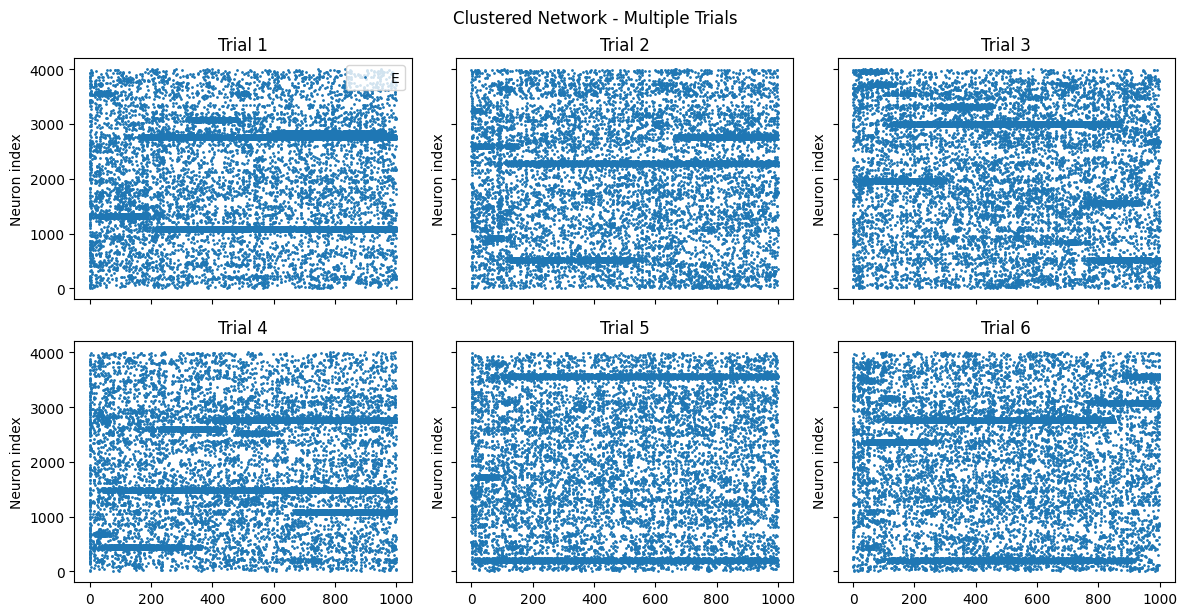

In [6]:
# Plot multiple trials in a grid
# Create a fresh network for the trial rasters
trial_network = NeuronNetwork(
    ModelParams(duration=1*second),  # Shorter duration for quick visualization
    ClusterParams(enabled=True, R_ee=2.5),
    seed=123
)

fig, axes = plot_trial_rasters(trial_network, n_trials=6, ncols=3, show_inhibitory=False)
fig.suptitle("Clustered Network - Multiple Trials", y=1.02)
plt.show()

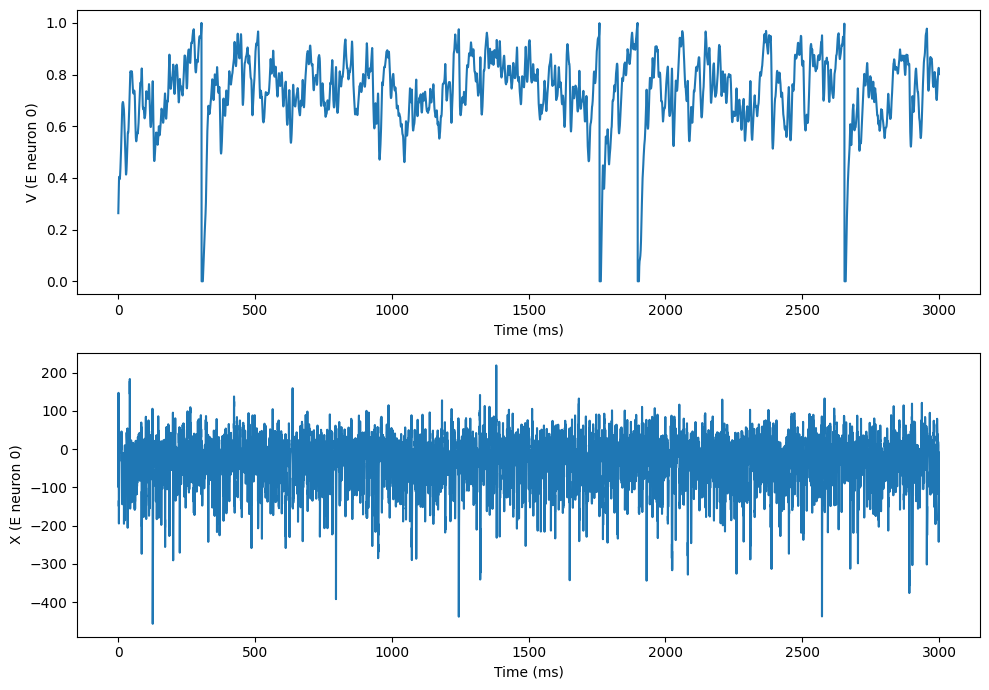

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [8]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

<Axes: title={'center': 'Spike raster'}, ylabel='Neuron index'>

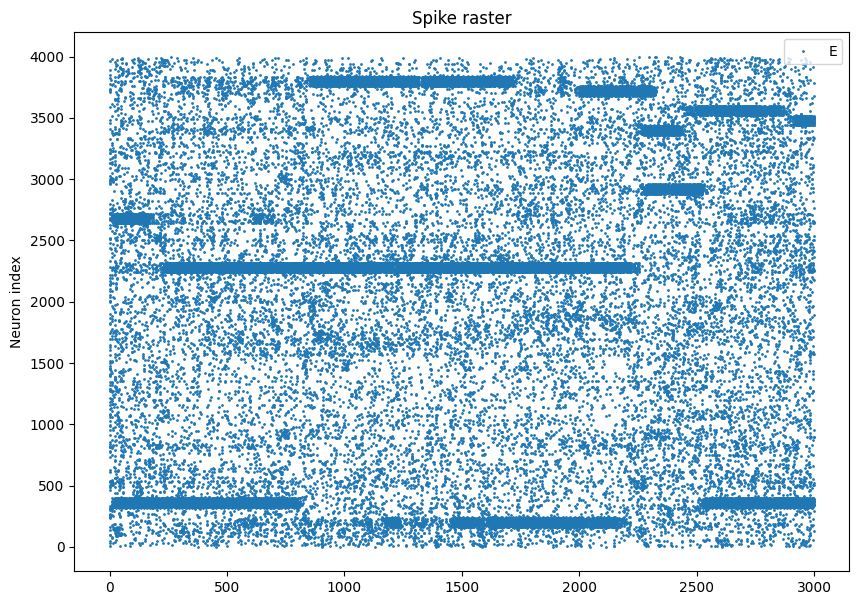

In [9]:
plot_spike_raster(clustered_network.spike_monitor_e)

## Plot the membrane potentials of a few neurons

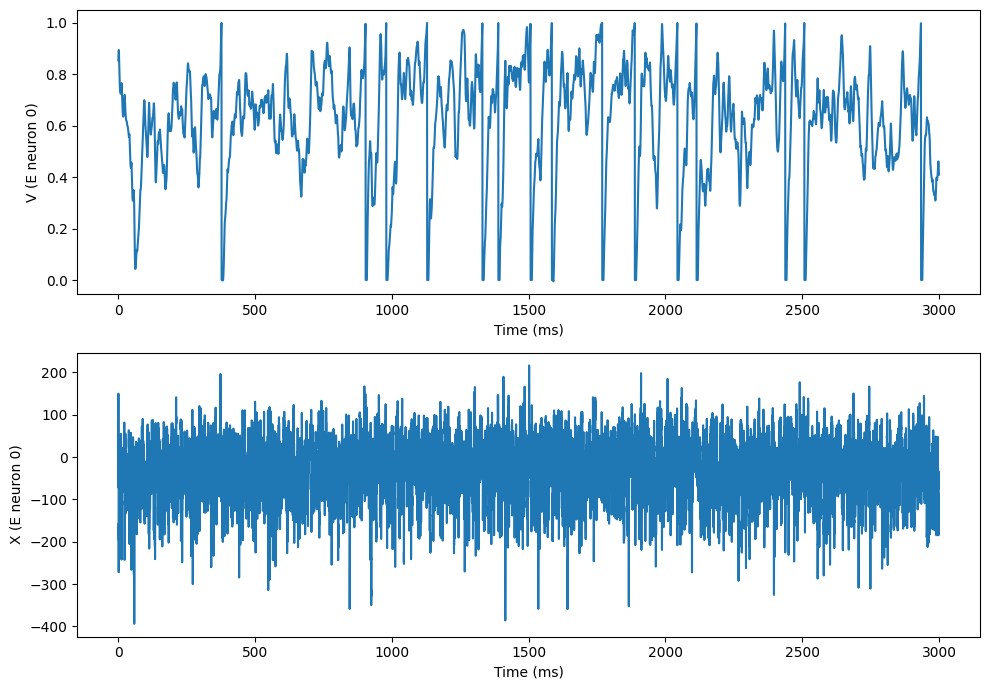

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)
(4000,) (1000,)
(5000,)


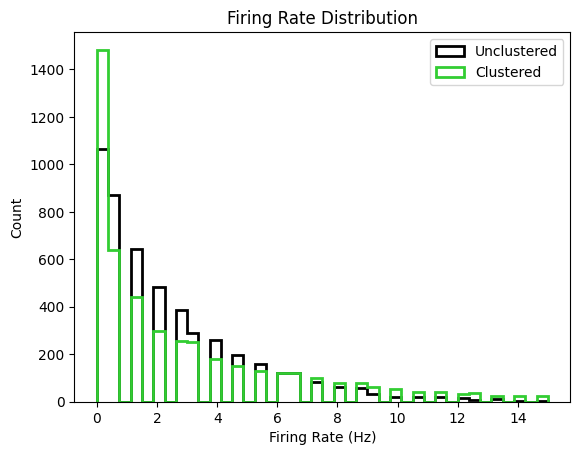

In [53]:
def plot_firing_rate_distribution(networks, labels, title, params):
    """Plot firing rate distribution for multiple networks."""
    fig, ax = plt.subplots()
    
    colors = {'Unclustered': 'black', 'Clustered': 'limegreen', 
              'Uniform': 'black'}

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=40,
            range=(0, 15),
            histtype='step',
            linewidth=2,
            color=colors.get(label, 'black'),
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

# Checking difference of exponential filter to an ODE

In [12]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clustered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

## Metrics

**Firing Rate**: Spikes per neuron divided by the analysis window duration (Hz).

**Fano Factor**: Variance-to-mean ratio of spike counts across trials. A Poisson process has FF=1; values >1 indicate higher variability (bursty firing).

**Correlation Coefficient**: Spikes are binned into sliding time windows to create a spike count time series per neuron. We overlap the sliding time windows. The correlation coefficient between neuron pairs is: $\rho_{ij} = \text{Cov}(X_i, X_j) / (\sigma_i \sigma_j)$.

In [77]:
from dataclasses import dataclass


@dataclass
class SpikeData:
    """Container for spike data from experiment runs."""
    uniform: list          # [realization][trial] = (spike_times, spike_ids)
    clustered: list        # [realization][trial] = (spike_times, spike_ids)
    model_params: ModelParams
    cluster_params: ClusterParams
    realizations: int
    trials: int


class Experiment:
    """Runs simulations and collects spike data."""
    
    def __init__(
        self,
        realizations=12,
        trials=9,
        model_params=ModelParams(),
        cluster_params=ClusterParams(enabled=True, R_ee=2.5),
        seed=42,
    ):
        self.realizations = realizations
        self.trials = trials
        self.model_params = model_params
        self.cluster_params = cluster_params
        self.seed = seed
        
        # Initialize networks
        self.uniform_networks = self._initialize_networks(
            ClusterParams(enabled=False, R_ee=1.0), "uniform"
        )
        self.clustered_networks = self._initialize_networks(
            cluster_params, "clustered"
        )

    def _initialize_networks(self, cluster_params, name):
        networks = []
        for r in range(self.realizations):
            network = NeuronNetwork(
                self.model_params, cluster_params, seed=self.seed + 1000 * r
            )
            print(f"Built {name} network {r + 1}/{self.realizations}")
            networks.append(network)
        return networks

    def run(self) -> SpikeData:
        """Run all simulations and return spike data."""
        uniform_spikes = self._run_networks(self.uniform_networks, "uniform")
        clustered_spikes = self._run_networks(self.clustered_networks, "clustered")
        
        return SpikeData(
            uniform=uniform_spikes,
            clustered=clustered_spikes,
            model_params=self.model_params,
            cluster_params=self.cluster_params,
            realizations=self.realizations,
            trials=self.trials,
        )

    def _run_networks(self, networks, name):
        """Run networks and collect spike data."""
        print(f"Running {name} networks...")
        all_spikes = []
        
        for r, network in enumerate(networks):
            trial_spikes = []
            for t in range(self.trials):
                network.run()
                spike_times = np.array(network.spike_monitor_e.t)
                spike_ids = np.array(network.spike_monitor_e.i)
                trial_spikes.append((spike_times, spike_ids))
                print(f"  Realization {r + 1}/{len(networks)}, Trial {t + 1}/{self.trials}")
            all_spikes.append(trial_spikes)
        
        return all_spikes


# =============================================================================
# Standalone analysis functions
# =============================================================================

def _count_spikes_in_window(spike_times, spike_ids, n_neurons, start_t, end_t):
    """Count spikes per neuron in a time window."""
    mask = (spike_times >= start_t) & (spike_times < end_t)
    return np.bincount(spike_ids[mask], minlength=n_neurons)


def compute_fano_factor(spike_data: SpikeData, window_t=None):
    """Compute Fano factor from spike data.
    
    Args:
        spike_data: SpikeData object
        window_t: Analysis window duration (default: model_params.fano_factor_window_t)
    
    Returns:
        (uniform_ff, clustered_ff): Fano factors of shape (realizations, N_E)
    """
    params = spike_data.model_params
    start_t = float(params.analysis_start_t)
    window_t = float(window_t or params.fano_factor_window_t)
    end_t = start_t + window_t
    n_e = params.N_E
    
    def compute_ff(spikes_list):
        counts = np.zeros((spike_data.realizations, spike_data.trials, n_e), dtype=np.int32)
        for r, trial_spikes in enumerate(spikes_list):
            for t, (times, ids) in enumerate(trial_spikes):
                counts[r, t, :] = _count_spikes_in_window(times, ids, n_e, start_t, end_t)
        
        mean = counts.mean(axis=1)
        var = counts.var(axis=1, ddof=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(mean > 0, var / mean, np.nan)
    
    return compute_ff(spike_data.uniform), compute_ff(spike_data.clustered)


def compute_firing_rates(spike_data: SpikeData, window_t=None):
    """Compute firing rates from spike data.
    
    Args:
        spike_data: SpikeData object
        window_t: Analysis window duration (default: model_params.firing_rate_window_t)
    
    Returns:
        (uniform_rates, clustered_rates): Flattened arrays of firing rates
    """
    params = spike_data.model_params
    start_t = float(params.analysis_start_t)
    window_t = float(window_t or params.firing_rate_window_t)
    end_t = start_t + window_t
    n_e = params.N_E
    
    def compute_rates(spikes_list):
        rates = np.zeros((spike_data.realizations, spike_data.trials, n_e), dtype=np.float64)
        for r, trial_spikes in enumerate(spikes_list):
            for t, (times, ids) in enumerate(trial_spikes):
                counts = _count_spikes_in_window(times, ids, n_e, start_t, end_t)
                rates[r, t, :] = counts / window_t
        return rates.ravel()
    
    return compute_rates(spike_data.uniform), compute_rates(spike_data.clustered)


def _window_spikes_all_neurons(spike_times, spike_ids, n_neurons, window, step, timerange):
    """Compute spike counts in sliding windows for all neurons."""
    start_time, end_time = float(timerange[0]), float(timerange[1])
    window, step = float(window), float(step)
    
    window_starts = np.arange(start_time, end_time - window + step, step)
    n_windows = len(window_starts)
    
    window_counts = np.zeros((n_neurons, n_windows), dtype=np.int32)
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids)
    
    for w, ws in enumerate(window_starts):
        mask = (spike_times >= ws) & (spike_times <= ws + window)
        window_counts[:, w] = np.bincount(spike_ids[mask], minlength=n_neurons)
    
    return window_counts


def compute_correlation_coefficients(spike_data: SpikeData, corr_window=50*ms, 
                                      corr_step=25*ms, same_cluster_only=False):
    """Compute correlation coefficients from spike data.
    
    Args:
        spike_data: SpikeData object
        corr_window: Sliding window size for binning
        corr_step: Step size for sliding window
        same_cluster_only: If True, only compute for same-cluster pairs
    
    Returns:
        (uniform_coeffs, clustered_coeffs): Arrays of correlation coefficients
    """
    params = spike_data.model_params
    cluster_params = spike_data.cluster_params
    start_t = params.analysis_start_t
    end_t = start_t + params.analysis_window_t
    timerange = (start_t, end_t)
    n_e = params.N_E
    total_trials = spike_data.realizations * spike_data.trials
    
    def compute_mean_cov_var(spikes_list):
        cov_sum = np.zeros((n_e, n_e), dtype=np.float64)
        var_sum = np.zeros(n_e, dtype=np.float64)
        
        for trial_spikes in spikes_list:
            for times, ids in trial_spikes:
                window_counts = _window_spikes_all_neurons(
                    times, ids, n_e, corr_window, corr_step, timerange
                )
                cov_sum += np.cov(window_counts, rowvar=True, bias=False)
                var_sum += np.var(window_counts, axis=1, ddof=1)
        
        return cov_sum / total_trials, var_sum / total_trials
    
    def calc_coeffs(cov_matrix, neuron_vars):
        coeffs = []
        if same_cluster_only and cluster_params.enabled:
            n_cluster = cluster_params.cluster_size
            for i in range(n_e):
                cluster_end = (i // n_cluster + 1) * n_cluster
                for j in range(i + 1, min(cluster_end, n_e)):
                    denom = np.sqrt(neuron_vars[i] * neuron_vars[j])
                    if denom > 0:
                        coeffs.append(cov_matrix[i, j] / denom)
        else:
            for i in range(n_e):
                for j in range(i + 1, n_e):
                    denom = np.sqrt(neuron_vars[i] * neuron_vars[j])
                    if denom > 0:
                        coeffs.append(cov_matrix[i, j] / denom)
        return np.array(coeffs)
    
    uniform_cov, uniform_var = compute_mean_cov_var(spike_data.uniform)
    clustered_cov, clustered_var = compute_mean_cov_var(spike_data.clustered)
    
    return calc_coeffs(uniform_cov, uniform_var), calc_coeffs(clustered_cov, clustered_var)

In [78]:
# =============================================================================
# Plotting functions for SpikeData analysis
# =============================================================================

def plot_firing_rate_distribution(spike_data: SpikeData, bins=20, rate_range=(0, 15), save_path=None):
    """Plot firing rate distribution for uniform and clustered networks."""
    uniform_rates, clustered_rates = compute_firing_rates(spike_data)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(uniform_rates, bins=bins, histtype='step', linewidth=2, color='black', 
            range=rate_range, label=f'Uniform (mean={np.mean(uniform_rates):.2f} Hz)')
    ax.hist(clustered_rates, bins=bins, histtype='step', linewidth=2, color='limegreen', 
            range=rate_range, label=f'Clustered (mean={np.mean(clustered_rates):.2f} Hz)')
    
    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(f'Firing Rate Distribution (Excitatory Neurons)\n'
                 f'{spike_data.realizations} realizations × {spike_data.trials} trials')
    ax.legend()
    
    # Add triangle markers for means
    y_top = ax.get_ylim()[1]
    ax.plot([np.mean(uniform_rates)], [y_top * 1.01], marker='v', 
            markersize=6, color='black', clip_on=False)
    ax.plot([np.mean(clustered_rates)], [y_top * 1.01], marker='v', 
            markersize=6, color='limegreen', clip_on=False)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_fano_factor(spike_data: SpikeData, save_path=None):
    """Plot Fano factor distribution for uniform and clustered networks."""
    uniform_ff, clustered_ff = compute_fano_factor(spike_data)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    bins = np.linspace(0, 3, 35)
    ax.hist(uniform_ff.ravel(), bins=bins, histtype='step', linewidth=2, color='black', label='Uniform')
    ax.hist(clustered_ff.ravel(), bins=bins, histtype='step', linewidth=2, color='limegreen', label='Clustered')
    
    uniform_mean = np.nanmean(uniform_ff)
    clustered_mean = np.nanmean(clustered_ff)
    
    ax.set_xlabel('Fano Factor')
    ax.set_ylabel('Count')
    ax.legend()
    
    # Add triangle markers for means
    y_top = ax.get_ylim()[1]
    ax.plot([uniform_mean], [y_top * 1.01], marker='v', 
            markersize=6, color='black', clip_on=False)
    ax.plot([clustered_mean], [y_top * 1.01], marker='v', 
            markersize=6, color='limegreen', clip_on=False)
    
    print(f"Mean Fano Factor (Uniform): {uniform_mean:.3f}")
    print(f"Mean Fano Factor (Clustered): {clustered_mean:.3f}")
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


def plot_correlation_coefficients(spike_data: SpikeData, corr_windows=None, corr_step=25*ms, save_path=None):
    """Plot correlation coefficient distributions for multiple window sizes.
    
    Args:
        spike_data: SpikeData object
        corr_windows: List of window sizes to compare (default: [50*ms, 100*ms])
        corr_step: Step size for sliding window
        save_path: Path to save figure
    """
    if corr_windows is None:
        corr_windows = [50*ms, 100*ms]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Colors for each window: (uniform_color, clustered_color)
    window_colors = [
        ('black', 'limegreen'),      # First window (50ms)
        ('gray', 'dodgerblue'),      # Second window (100ms)
        ('darkred', 'orange'),       # Third window (if needed)
        ('purple', 'cyan'),          # Fourth window (if needed)
    ]
    
    bins_all = np.linspace(-0.5, 0.5, 50)
    bins_cluster = np.linspace(-0.5, 1.0, 50)
    
    for w_idx, corr_window in enumerate(corr_windows):
        window_ms = int(corr_window / ms)
        uniform_color, clustered_color = window_colors[w_idx % len(window_colors)]
        
        # All pairs
        uniform_coeffs, clustered_coeffs = compute_correlation_coefficients(
            spike_data, corr_window, corr_step, same_cluster_only=False
        )
        
        axes[0].hist(uniform_coeffs, bins=bins_all, histtype='step', linewidth=2, 
                     color=uniform_color, label=f'Uniform ({window_ms}ms)')
        axes[0].hist(clustered_coeffs, bins=bins_all, histtype='step', linewidth=2, 
                     color=clustered_color, label=f'Clustered ({window_ms}ms)')
        
        # Same cluster pairs only
        uniform_cluster_coeffs, clustered_cluster_coeffs = compute_correlation_coefficients(
            spike_data, corr_window, corr_step, same_cluster_only=True
        )
        
        axes[1].hist(uniform_cluster_coeffs, bins=bins_cluster, histtype='step', 
                     linewidth=2, color=uniform_color, label=f'Uniform ({window_ms}ms)')
        axes[1].hist(clustered_cluster_coeffs, bins=bins_cluster, histtype='step', 
                     linewidth=2, color=clustered_color, label=f'Clustered ({window_ms}ms)')
        
        print(f"Window {window_ms}ms:")
        print(f"  Mean correlation (all pairs) - Uniform: {np.nanmean(uniform_coeffs):.4f}, "
              f"Clustered: {np.nanmean(clustered_coeffs):.4f}")
        print(f"  Mean correlation (same cluster) - Uniform: {np.nanmean(uniform_cluster_coeffs):.4f}, "
              f"Clustered: {np.nanmean(clustered_cluster_coeffs):.4f}")
    
    axes[0].set_xlabel('Correlation Coefficient (all pairs)')
    axes[0].set_ylabel('Count')
    axes[0].set_xlim(-0.5, 0.5)
    axes[0].legend()
    
    fmt0 = ScalarFormatter(useMathText=True)
    fmt0.set_powerlimits((6, 6))
    axes[0].yaxis.set_major_formatter(fmt0)
    
    axes[1].set_xlabel('Correlation Coefficient (same cluster)')
    axes[1].set_ylabel('Count')
    axes[1].set_xlim(-0.5, 1.0)
    axes[1].legend()
    
    fmt1 = ScalarFormatter(useMathText=True)
    fmt1.set_powerlimits((4, 4))
    axes[1].yaxis.set_major_formatter(fmt1)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, axes


def plot_fano_vs_ree(R_ee_values, mean_fano_factors, save_path=None):
    """Plot Fano factor as a function of cluster strength R_ee.
    
    Args:
        R_ee_values: Array of R_ee values tested
        mean_fano_factors: Array of mean Fano factors for each R_ee
        save_path: Path to save figure (optional)
    
    Returns:
        (fig, ax): Matplotlib figure and axes
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.plot(R_ee_values, mean_fano_factors, 'o-', color='black', linewidth=2, markersize=6)
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Poisson (FF=1)')
    
    ax.set_xlabel('$R_{EE}$ (cluster strength)')
    ax.set_ylabel('Mean Fano Factor')
    ax.set_title('Fano Factor vs Cluster Strength')
    ax.legend()
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

In [ ]:
# Run experiment with fewer realizations/trials for testing
experiment = Experiment(
    realizations=3, 
    trials=9, 
    model_params=ModelParams(duration=3*second),
    cluster_params=ClusterParams(enabled=True, R_ee=2.5),
)
spike_data = experiment.run()

Built uniform network 1/3
Built uniform network 2/3
Built uniform network 3/3
Built clustered network 1/3
Built clustered network 2/3
Built clustered network 3/3
Running uniform networks...
  Realization 1/3, Trial 1/9
  Realization 1/3, Trial 2/9
  Realization 1/3, Trial 3/9
  Realization 1/3, Trial 4/9
  Realization 1/3, Trial 5/9
  Realization 1/3, Trial 6/9
  Realization 1/3, Trial 7/9
  Realization 1/3, Trial 8/9
  Realization 1/3, Trial 9/9
  Realization 2/3, Trial 1/9
  Realization 2/3, Trial 2/9
  Realization 2/3, Trial 3/9
  Realization 2/3, Trial 4/9
  Realization 2/3, Trial 5/9
  Realization 2/3, Trial 6/9
  Realization 2/3, Trial 7/9
  Realization 2/3, Trial 8/9
  Realization 2/3, Trial 9/9
  Realization 3/3, Trial 1/9
  Realization 3/3, Trial 2/9
  Realization 3/3, Trial 3/9
  Realization 3/3, Trial 4/9
  Realization 3/3, Trial 5/9
  Realization 3/3, Trial 6/9
  Realization 3/3, Trial 7/9
  Realization 3/3, Trial 8/9
  Realization 3/3, Trial 9/9
Running clustered networks.

Mean Fano Factor (Uniform): 0.854
Mean Fano Factor (Clustered): 1.852


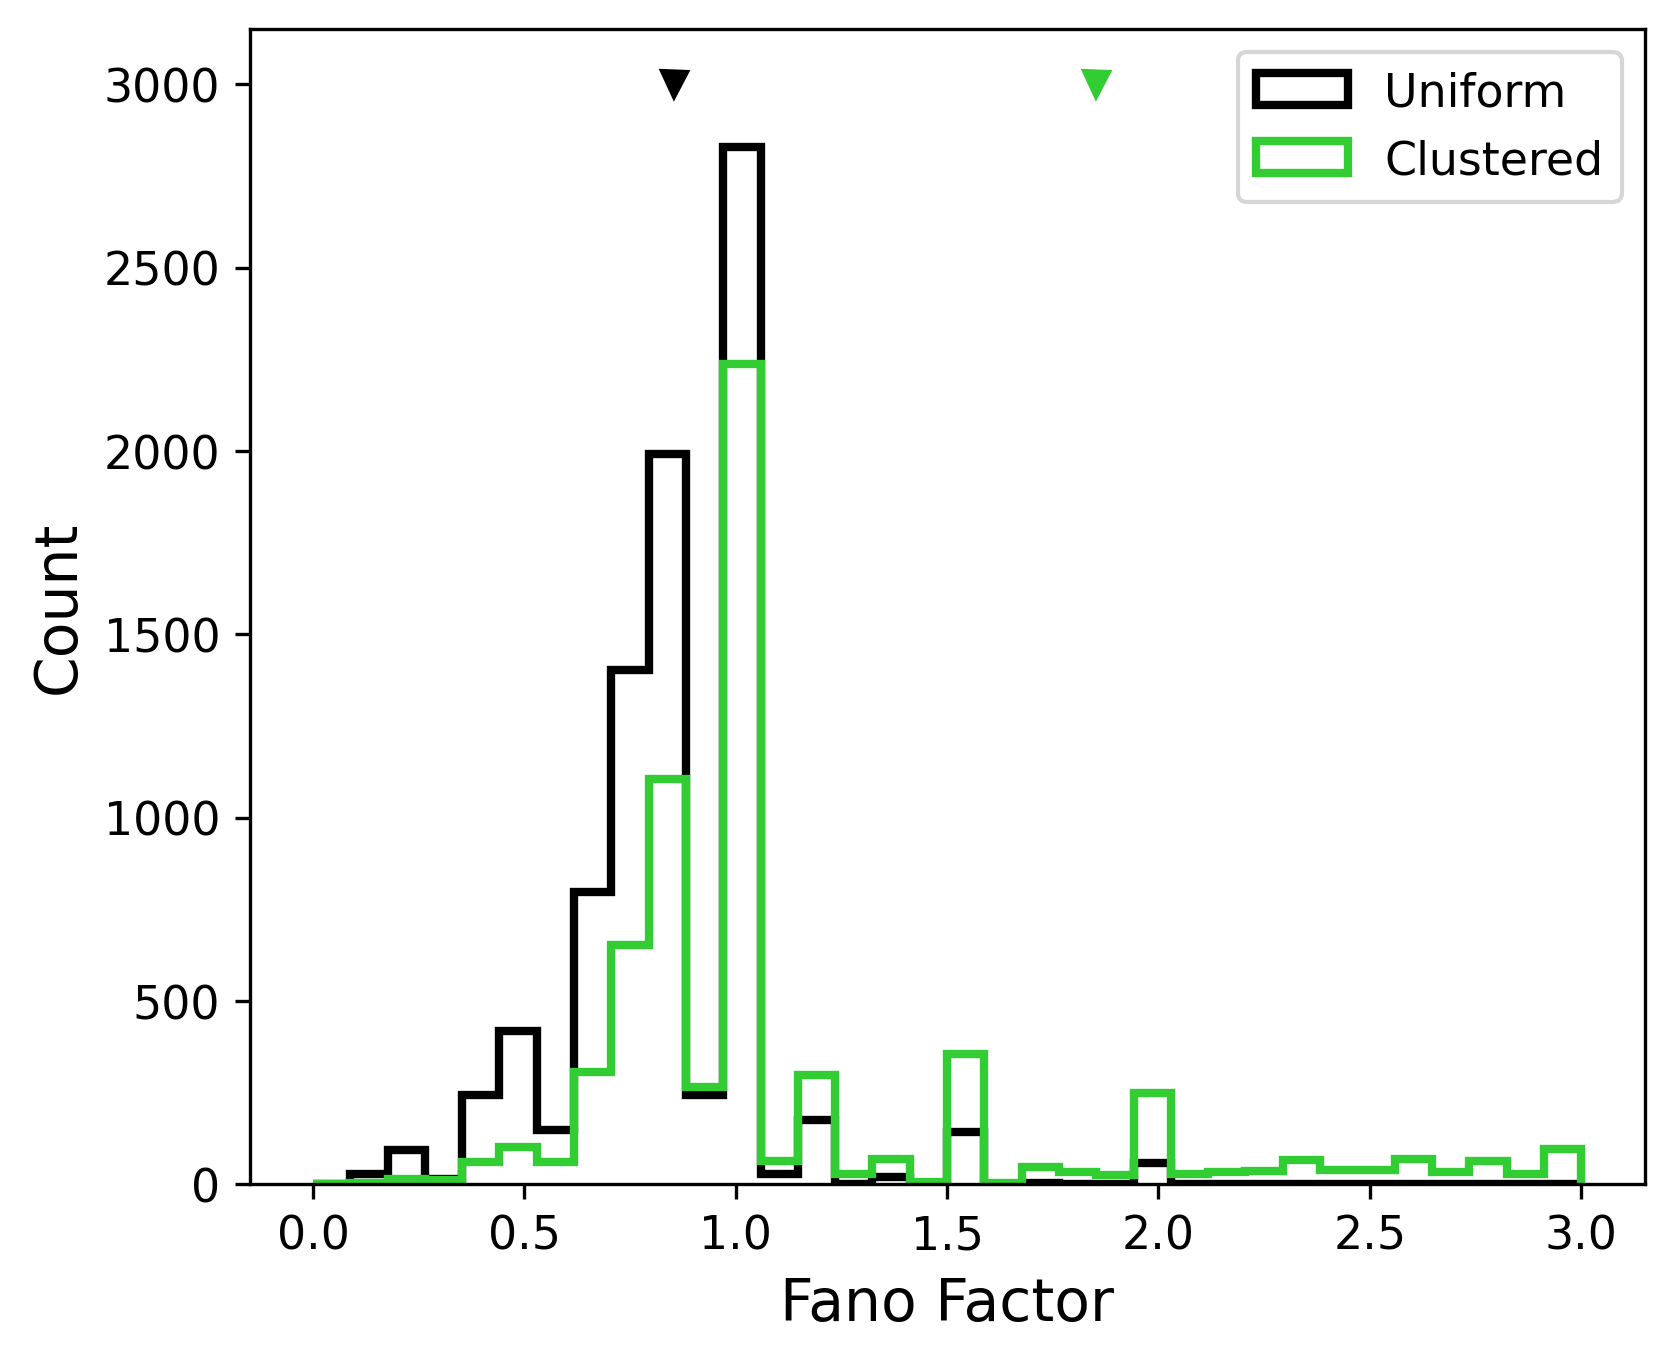

In [80]:
plot_fano_factor(spike_data)
plt.show()

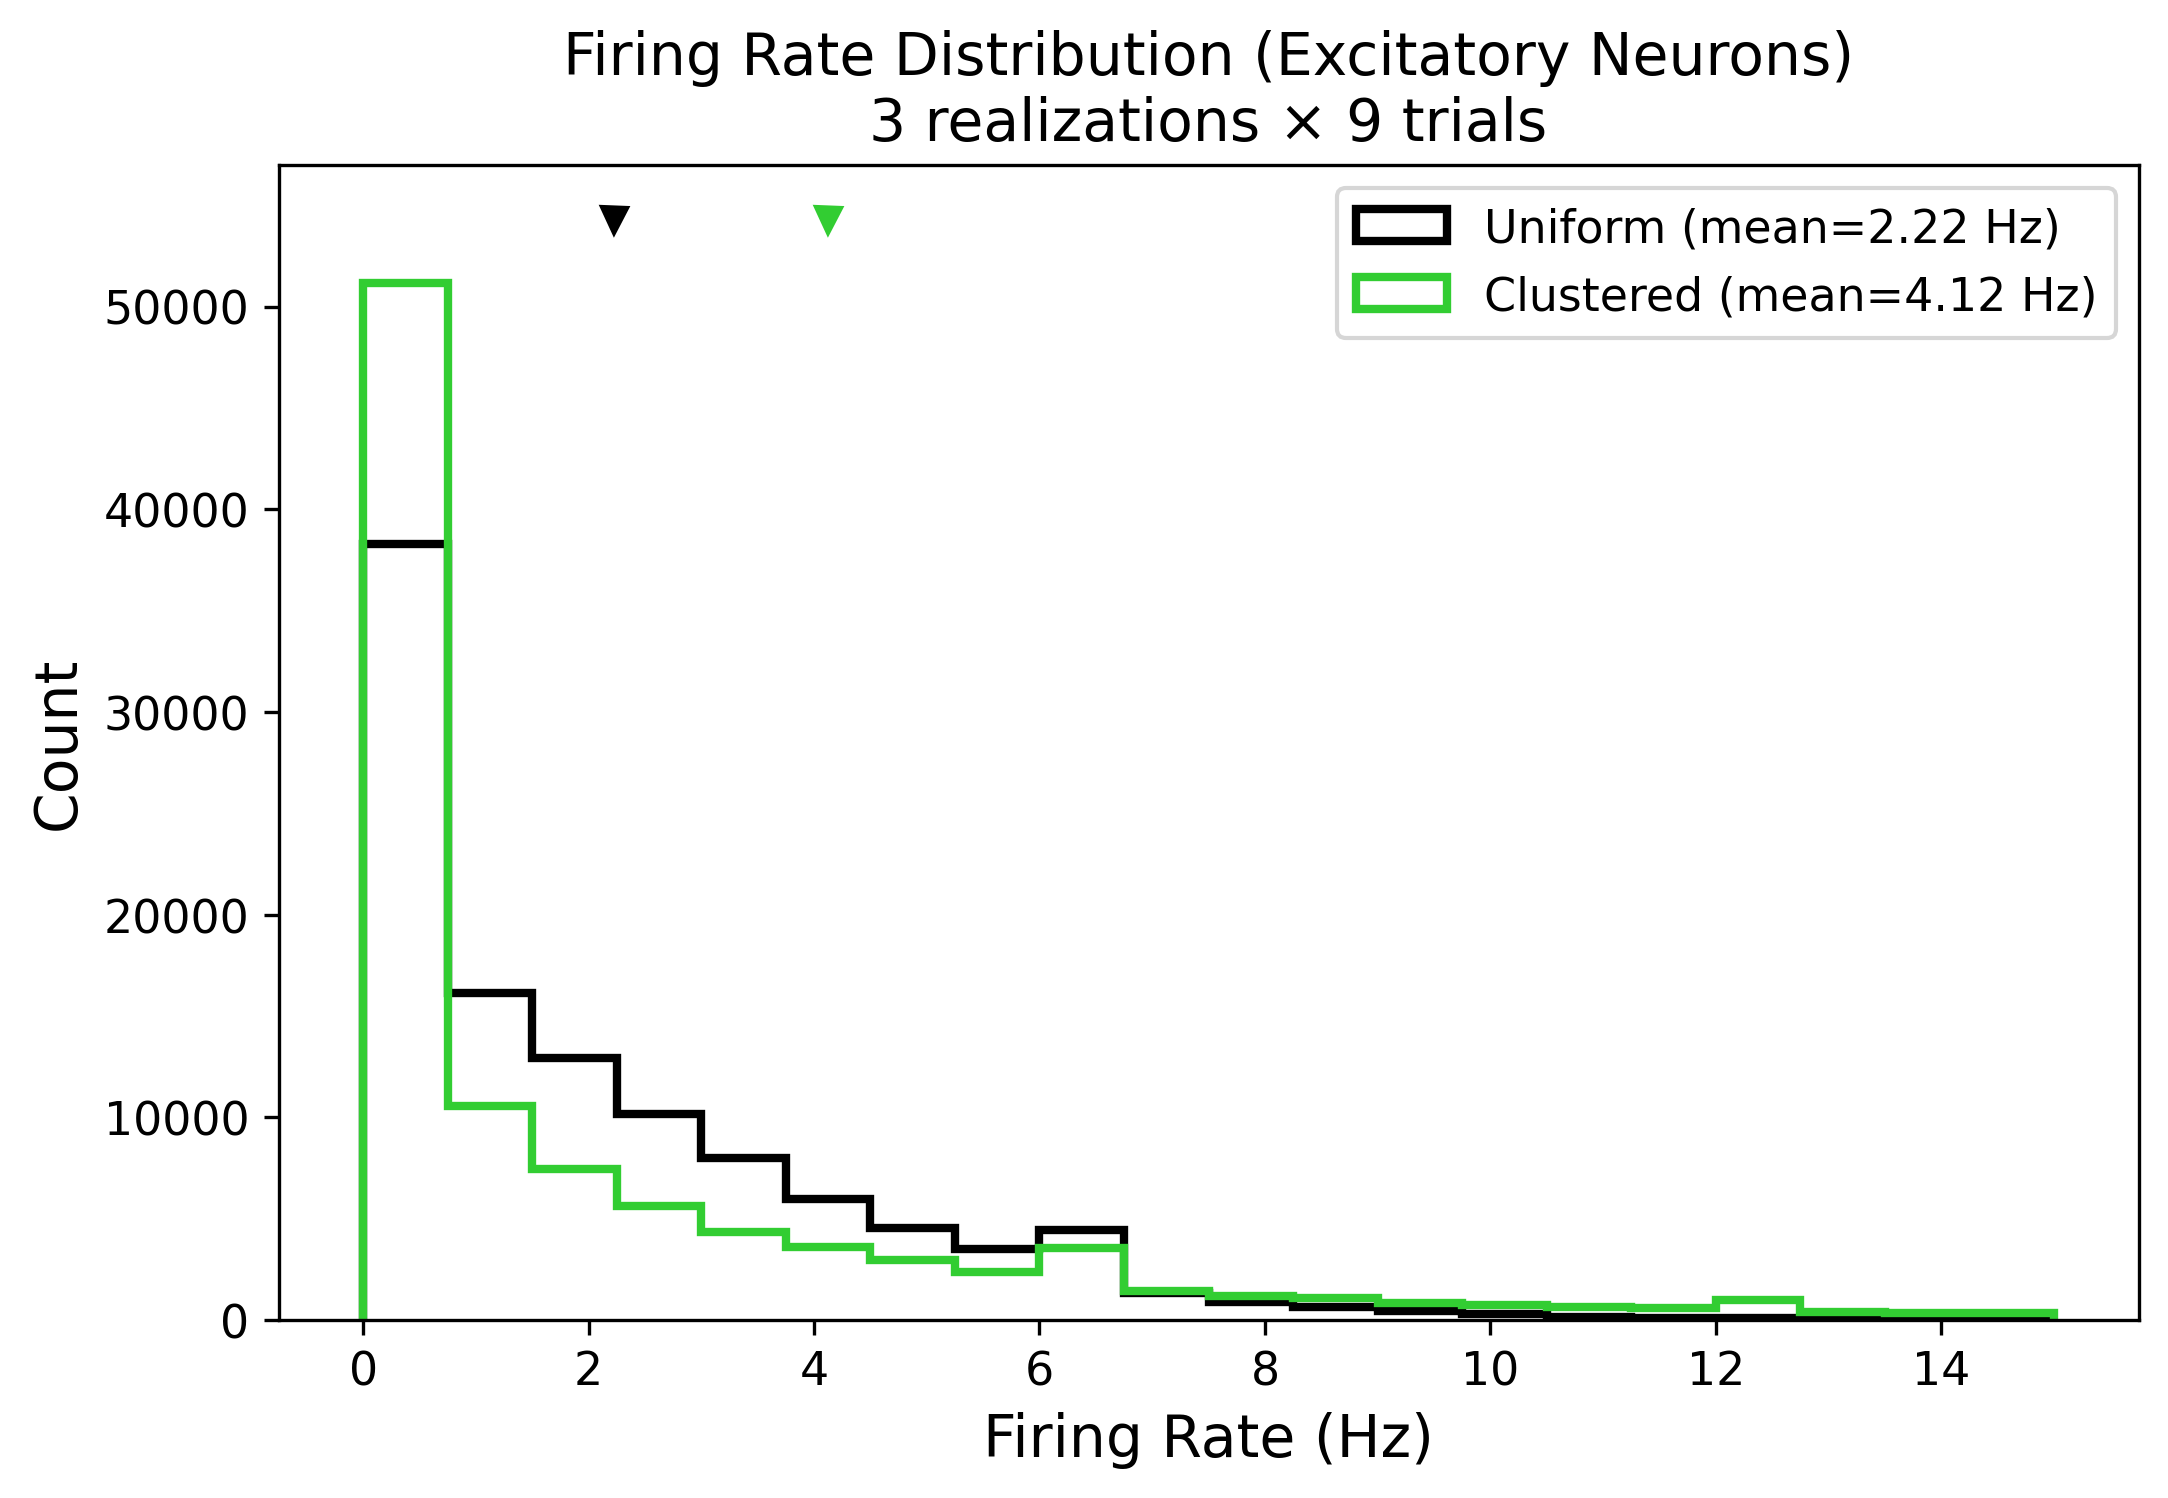

In [81]:
plot_firing_rate_distribution(spike_data)
plt.show()

Window 50ms:
  Mean correlation (all pairs) - Uniform: 0.0005, Clustered: 0.0008
  Mean correlation (same cluster) - Uniform: 0.0005, Clustered: 0.4111
Window 100ms:
  Mean correlation (all pairs) - Uniform: 0.0003, Clustered: 0.0009
  Mean correlation (same cluster) - Uniform: 0.0005, Clustered: 0.4985


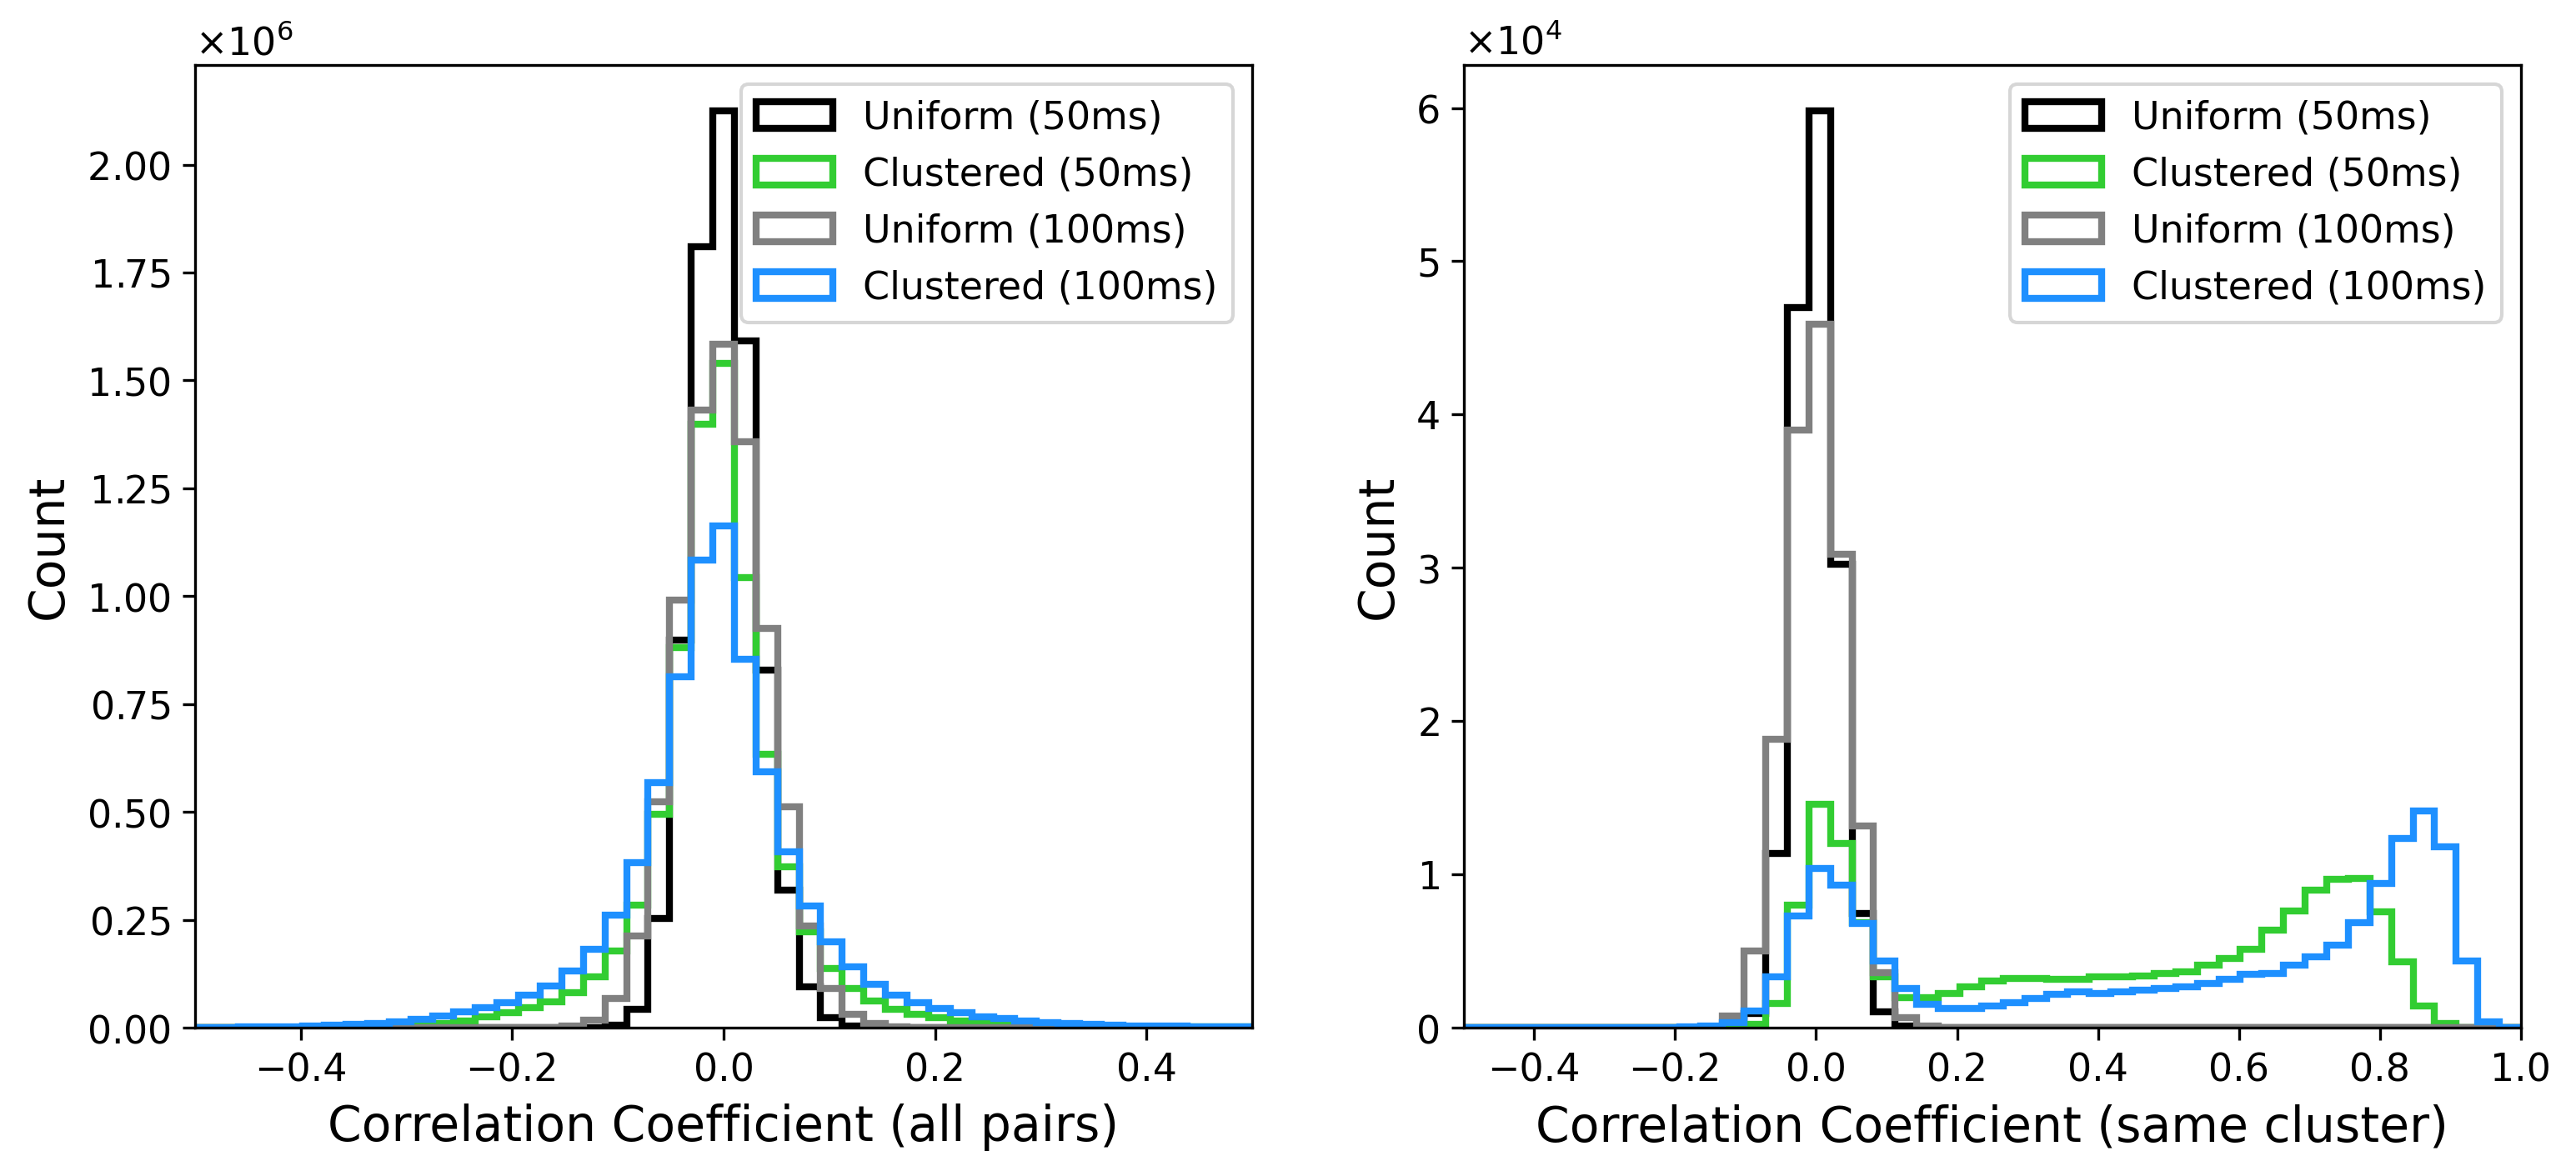

In [82]:
plot_correlation_coefficients(spike_data)
plt.show()

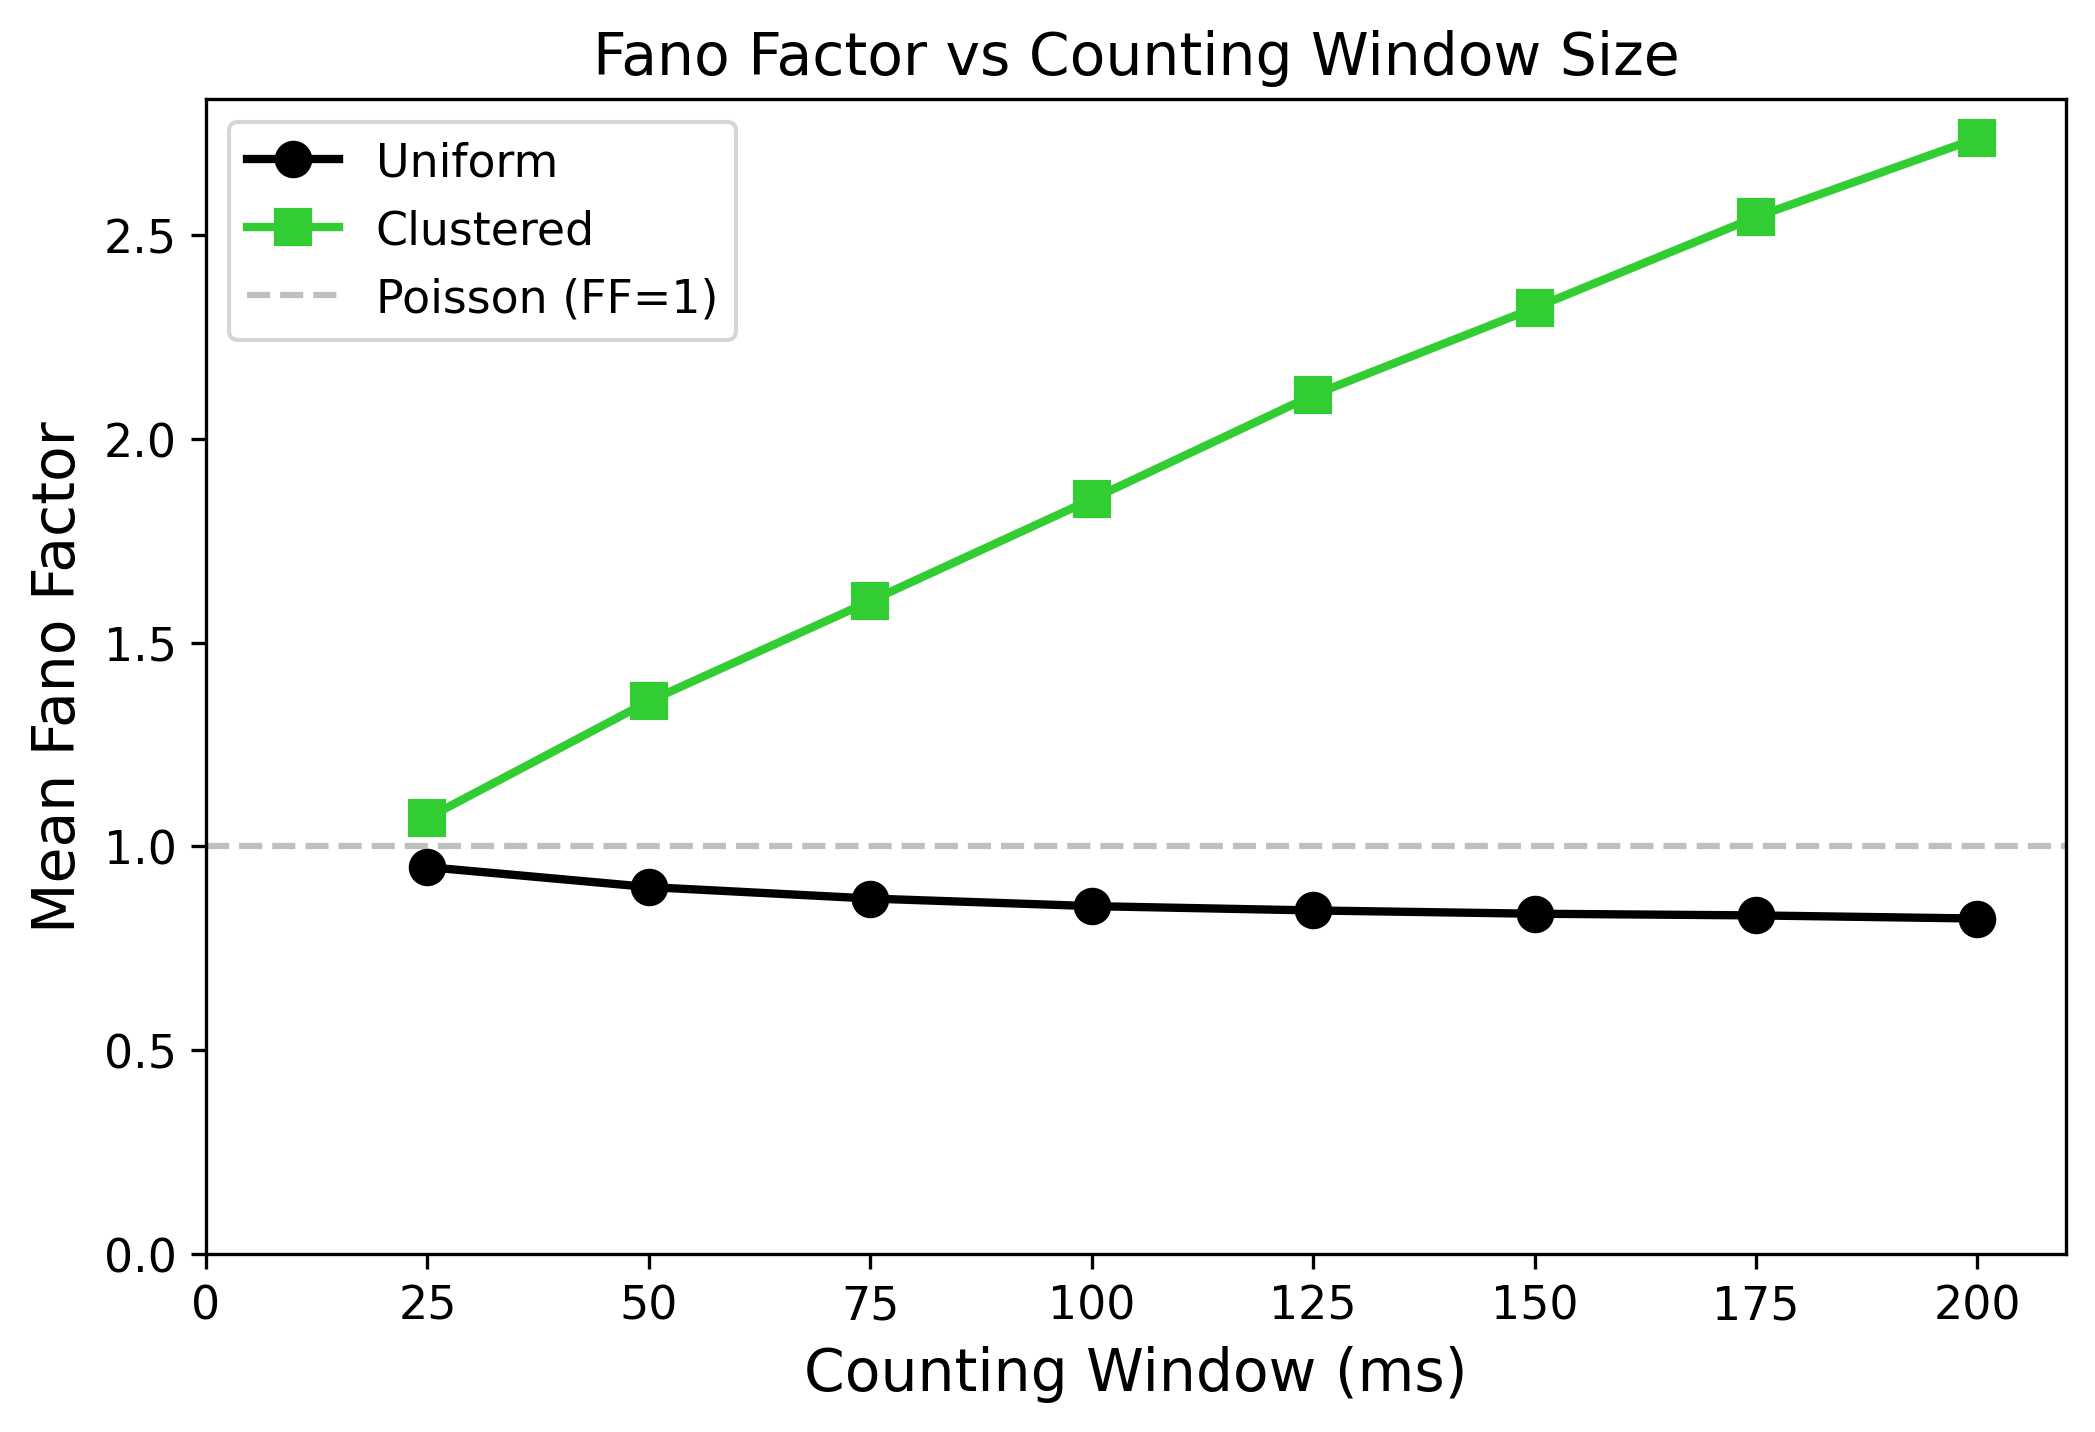

In [83]:
def plot_fano_vs_window(spike_data: SpikeData, window_times_ms=None, save_path=None):
    """Plot Fano factor as a function of analysis window size."""
    if window_times_ms is None:
        window_times_ms = [25, 50, 75, 100, 125, 150, 175, 200]
    
    uniform_ffs = []
    clustered_ffs = []

    for window_ms in window_times_ms:
        window_t = window_ms / 1000.0
        uniform_ff, clustered_ff = compute_fano_factor(spike_data, window_t=window_t)
        uniform_ffs.append(np.nanmean(uniform_ff))
        clustered_ffs.append(np.nanmean(clustered_ff))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(window_times_ms, uniform_ffs, 'o-', color='black', linewidth=2, markersize=8, label='Uniform')
    ax.plot(window_times_ms, clustered_ffs, 's-', color='limegreen', linewidth=2, markersize=8, label='Clustered')
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Poisson (FF=1)')
    ax.set_xlabel('Counting Window (ms)')
    ax.set_ylabel('Mean Fano Factor')
    ax.set_title('Fano Factor vs Counting Window Size')
    ax.legend()
    ax.set_xlim(0, max(window_times_ms) + 10)
    ax.set_ylim(0, None)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax


plot_fano_vs_window(spike_data)
plt.show()

## Stimulus Experiment

In [84]:
def plot_stim_raster(stim):
    fig, (ax_r, ax_s) = plt.subplots(
            2, 1, sharex=True, figsize=(10, 6),
            gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
        )
    
    ax_r.tick_params(labelbottom=False)
    intervals = [stim] if isinstance(stim, tuple) else stim
    for t0, t1 in intervals:
        ax_s.axvspan(t0/ms, t1/ms, color="k", alpha=1)
    ax_s.set_ylabel("Stim")
    ax_s.set_yticks([])
    ax_s.set_xlabel("Time (ms)")
    return (ax_r, ax_s)

In [85]:
N_E = 4000
multipliers_2 = np.full((60), 2)
multipliers_1 = np.ones((N_E-60))
multipliers = np.hstack((multipliers_2, multipliers_1))
stimulus_time = (1.5*second,2.5*second)
params = ModelParams(stimulus_multipliers=multipliers, stimulus_time=stimulus_time)


In [86]:
cluster_params = ClusterParams(enabled=True, R_ee=2.5)
clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

In [87]:
cluster_params = ClusterParams(enabled=False, R_ee=1.0)
unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

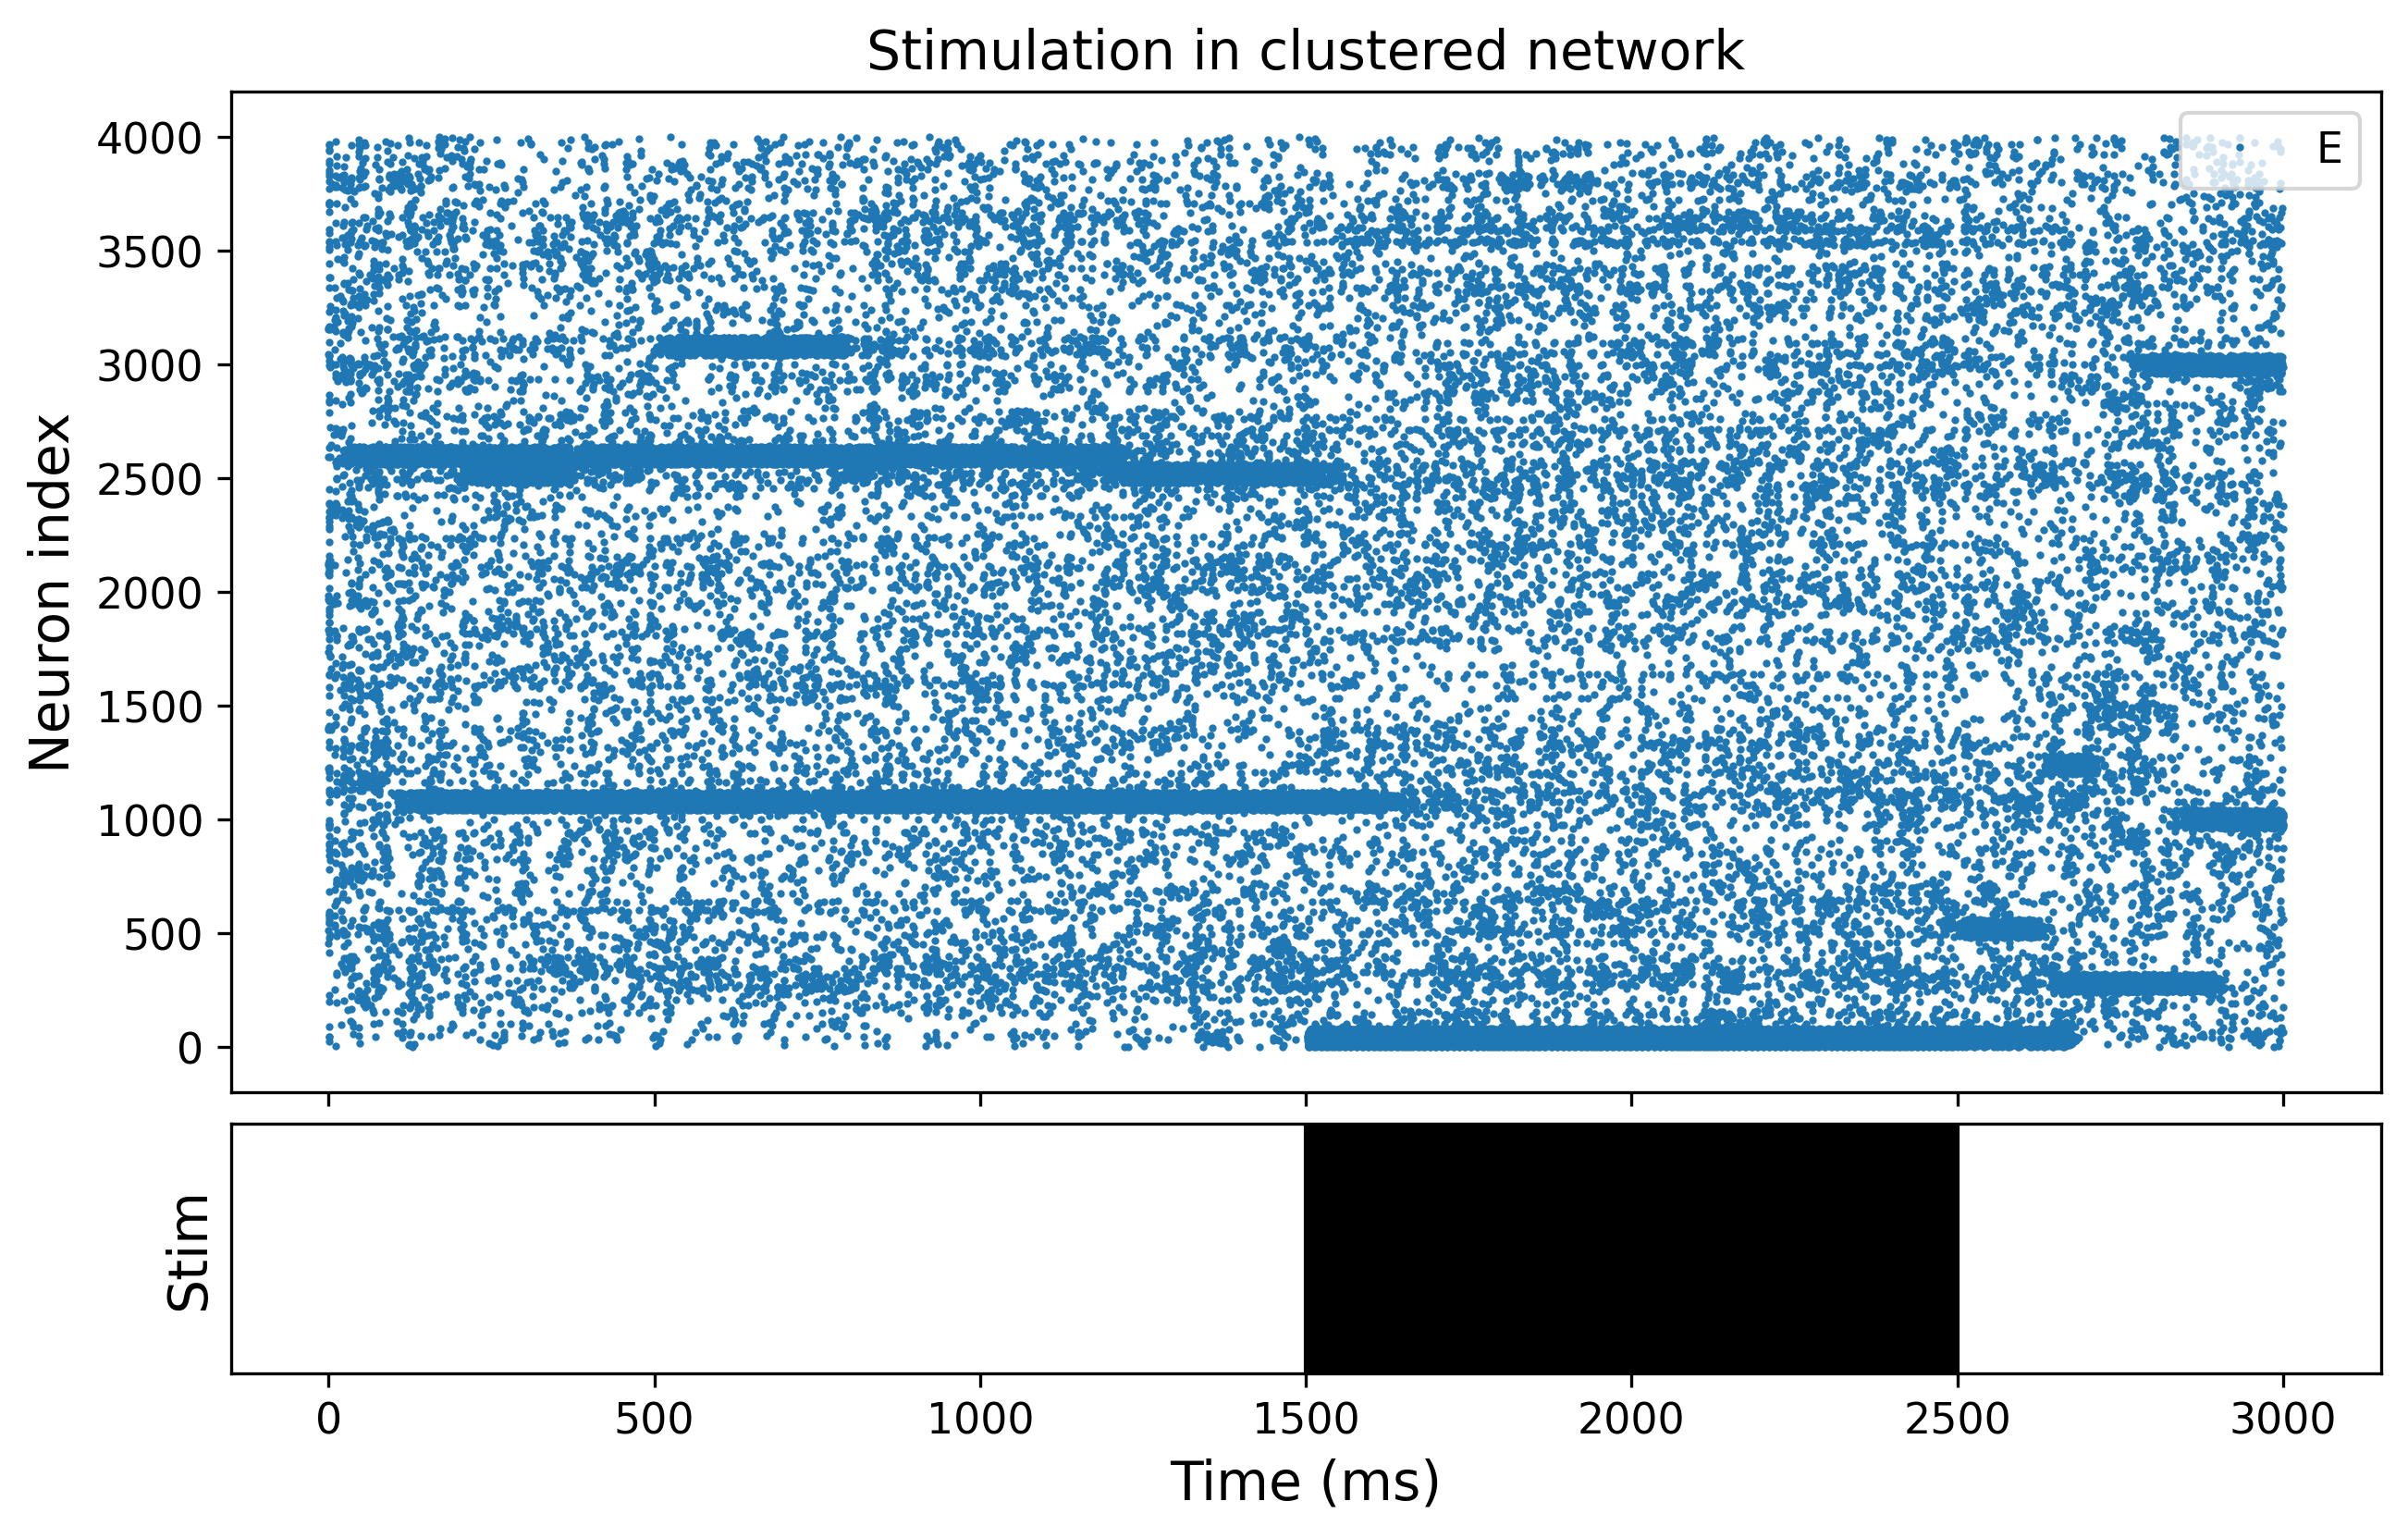

In [88]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    clustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in clustered network",
    ax=axes[0]
)
plt.show()

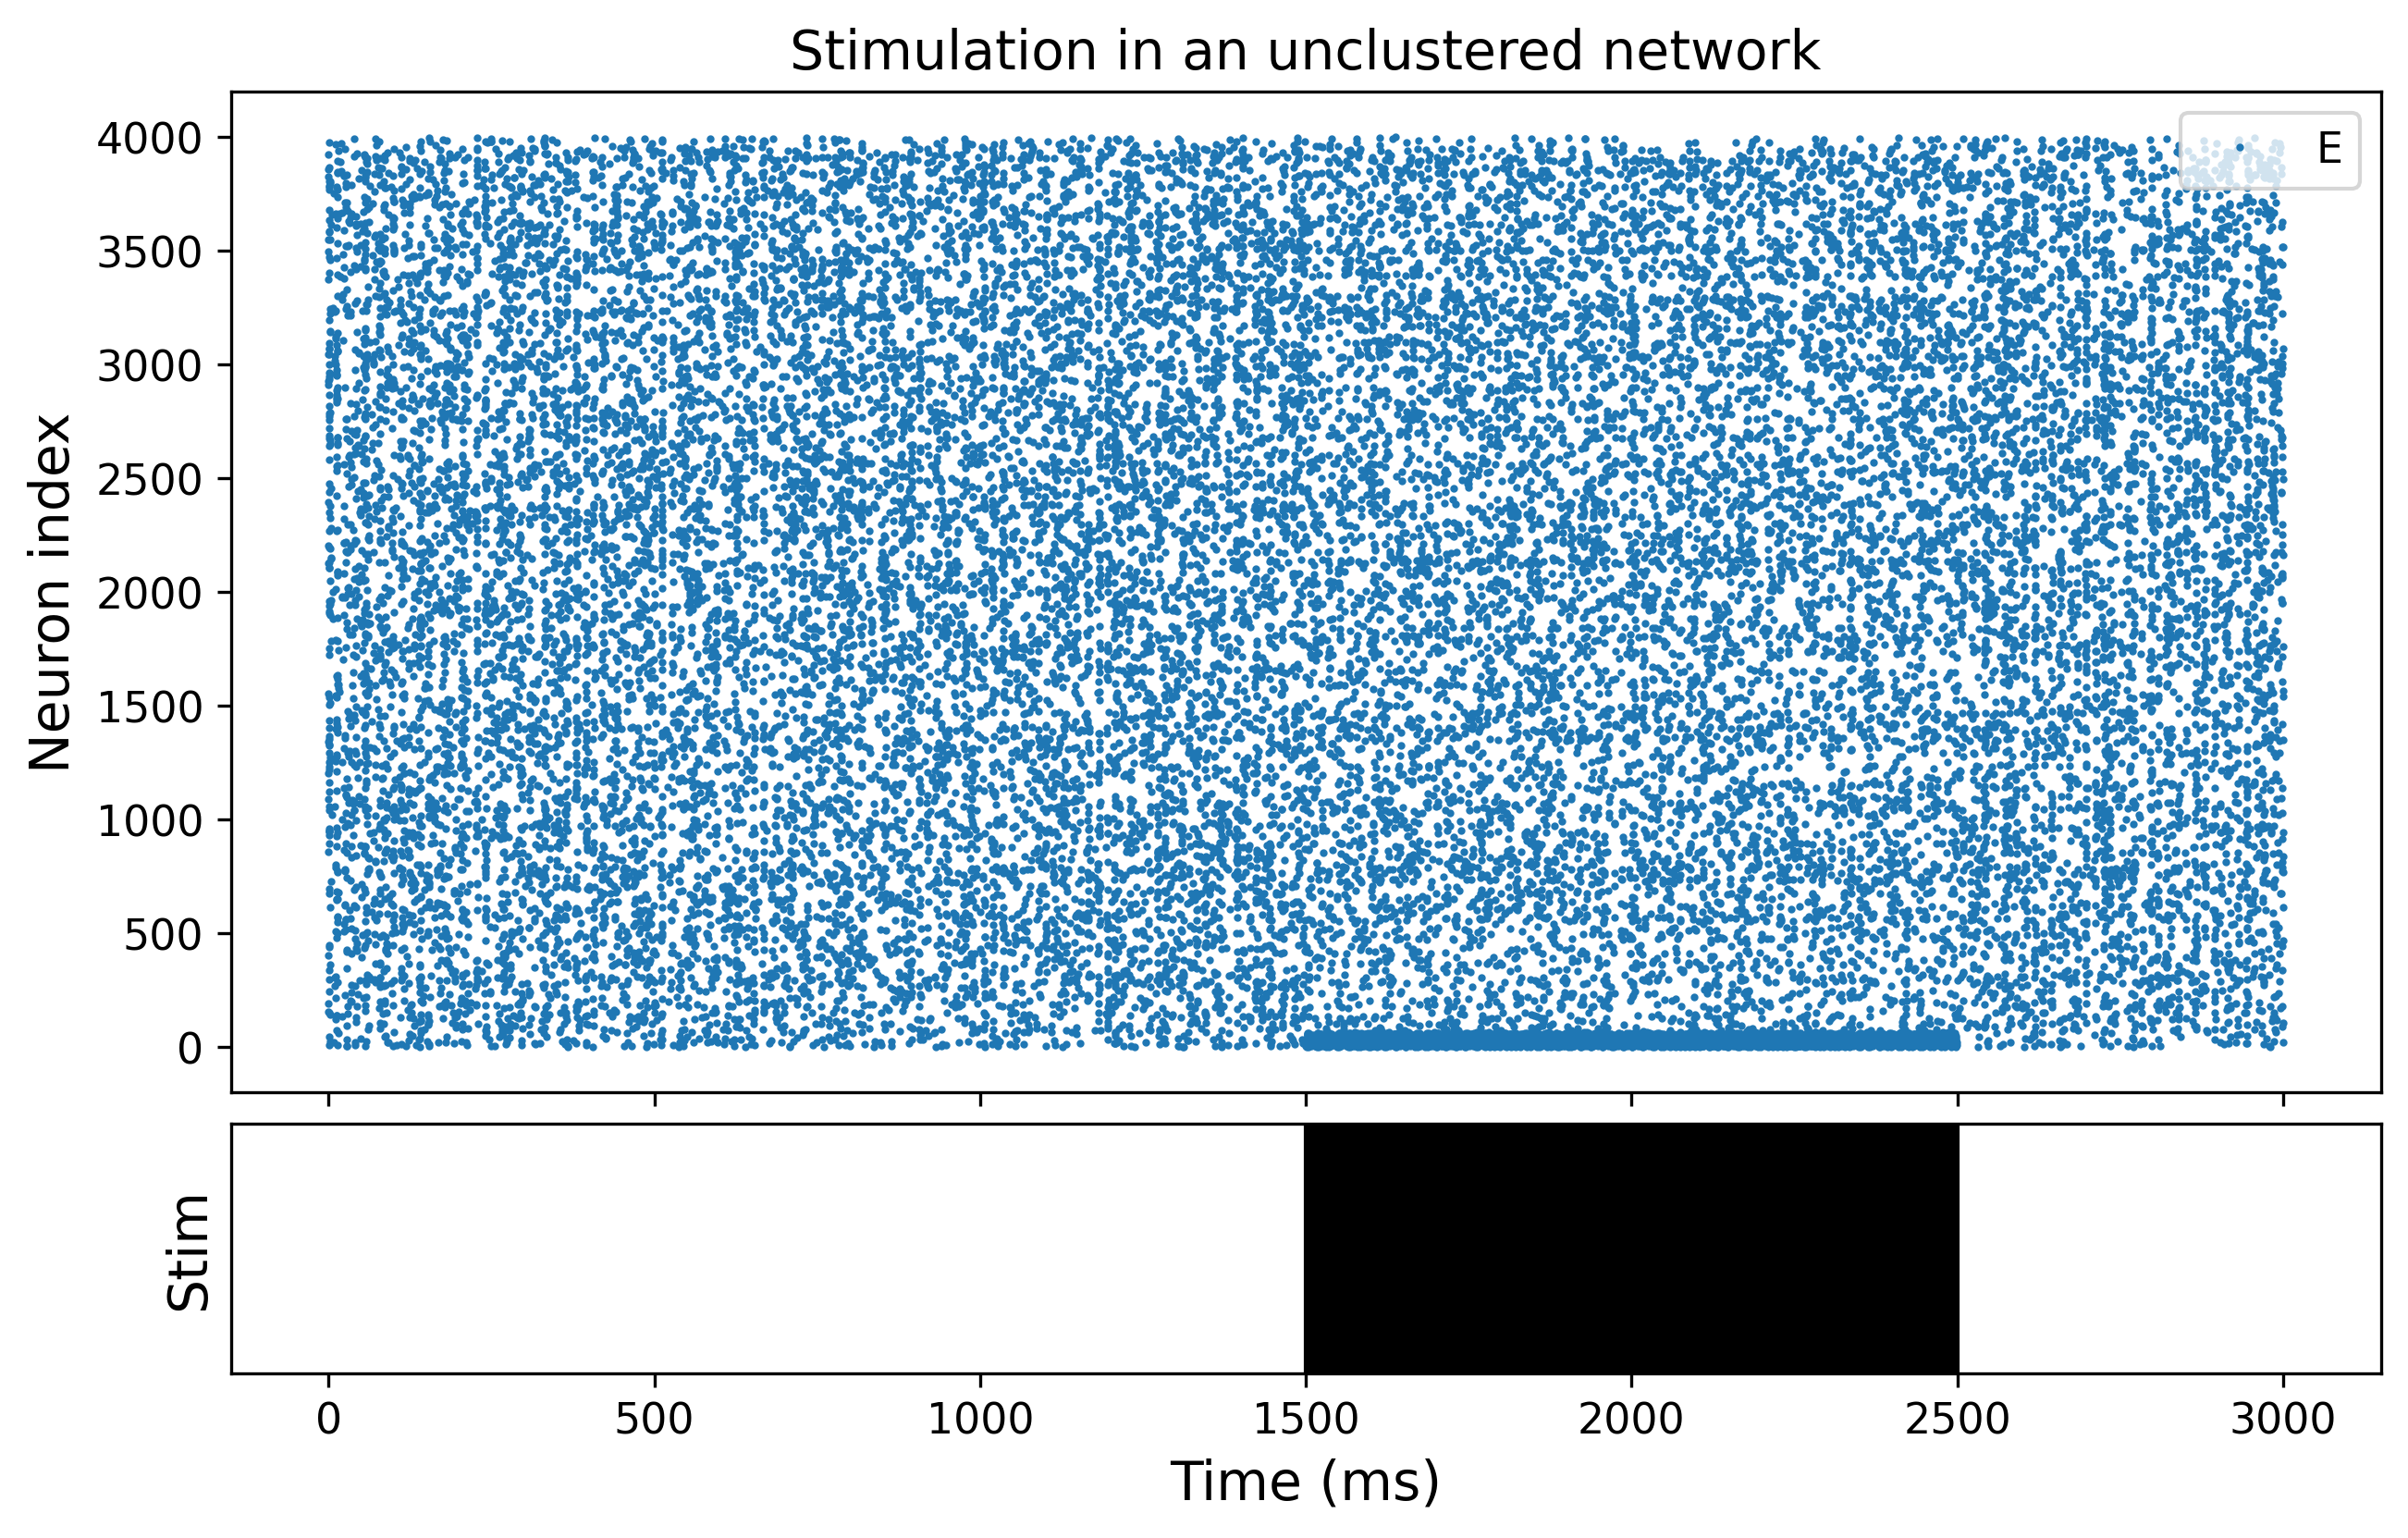

In [89]:
axes = plot_stim_raster(stimulus_time)
plot_spike_raster(
    unclustered_network.spike_monitor_e,
    n_e=params.N_E,
    title="Stimulation in an unclustered network",
    ax=axes[0]
)
plt.show()

# Comparing Fano Factor 

In [90]:
# =============================================================================
# Fano Factor vs R_ee Analysis
# =============================================================================

def compute_fano_factor_for_ree(R_ee_values, n_trials=3, duration=3*second, seed=42):
    """Compute mean Fano Factor for networks with different R_ee values."""
    mean_fano_factors = []
    model_params = ModelParams(duration=duration)
    
    for R_ee in R_ee_values:
        print(f"Running R_ee = {R_ee}...")
        
        cluster_params = ClusterParams(enabled=True, R_ee=R_ee)
        network = NeuronNetwork(model_params, cluster_params, seed=seed)
        
        # Collect spike data from trials
        trial_spikes = []
        for t in range(n_trials):
            network.run()
            spike_times = np.array(network.spike_monitor_e.t)
            spike_ids = np.array(network.spike_monitor_e.i)
            trial_spikes.append((spike_times, spike_ids))
        
        # Create SpikeData with only clustered data
        spike_data = SpikeData(
            uniform=[],  # Empty - not needed
            clustered=[trial_spikes],  # 1 realization
            model_params=model_params,
            cluster_params=cluster_params,
            realizations=1,
            trials=n_trials,
        )
        
        # Compute Fano factor (only use clustered result)
        _, clustered_ff = compute_fano_factor(spike_data)
        
        mean_ff = np.nanmean(clustered_ff)
        mean_fano_factors.append(mean_ff)
        print(f"  Mean Fano Factor: {mean_ff:.3f}")
    
    return np.array(mean_fano_factors)


# Run the analysis with finer R_ee resolution
R_ee_values = np.arange(1.0, 4.25, 0.25)
mean_fano_factors = compute_fano_factor_for_ree(R_ee_values, n_trials=9)


Running R_ee = 1.0...
  Mean Fano Factor: 0.840
Running R_ee = 1.25...
  Mean Fano Factor: 0.833
Running R_ee = 1.5...
  Mean Fano Factor: 0.823
Running R_ee = 1.75...
  Mean Fano Factor: 0.822
Running R_ee = 2.0...
  Mean Fano Factor: 0.840
Running R_ee = 2.25...
  Mean Fano Factor: 1.101
Running R_ee = 2.5...
  Mean Fano Factor: 1.519
Running R_ee = 2.75...
  Mean Fano Factor: 2.655
Running R_ee = 3.0...
  Mean Fano Factor: 4.121
Running R_ee = 3.25...
  Mean Fano Factor: 5.394
Running R_ee = 3.5...
  Mean Fano Factor: 6.195
Running R_ee = 3.75...
  Mean Fano Factor: 6.583
Running R_ee = 4.0...
  Mean Fano Factor: 7.365


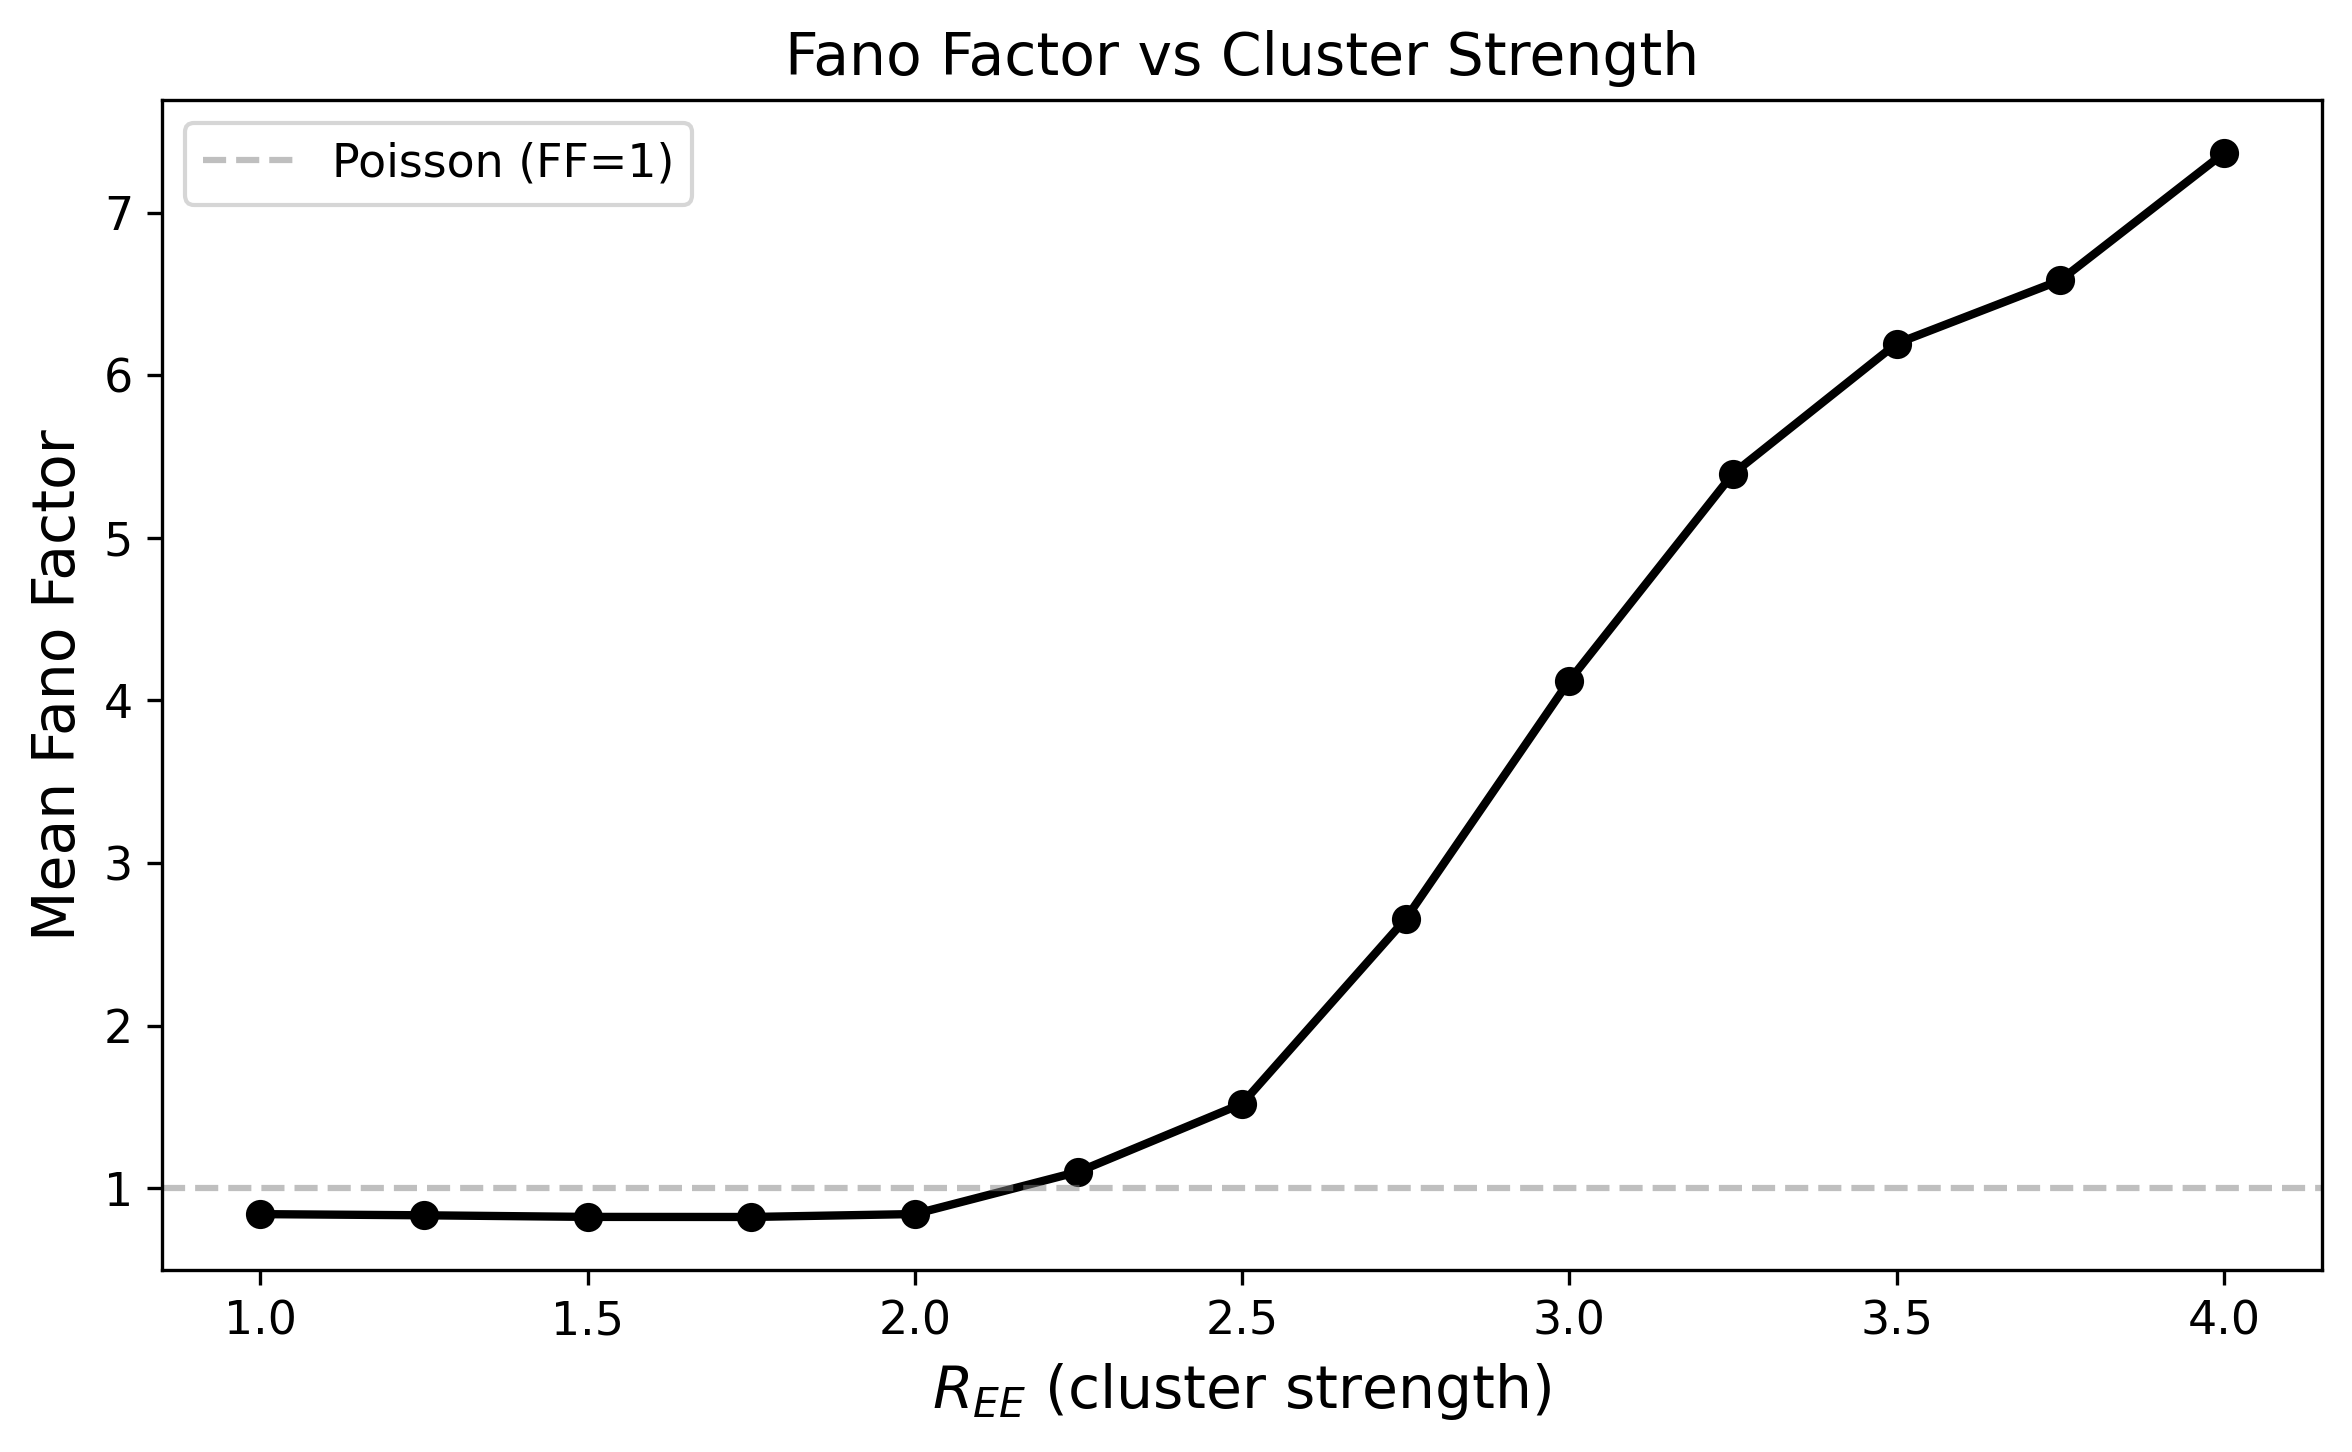

In [91]:
plot_fano_vs_ree(R_ee_values, mean_fano_factors)
plt.show()

In [92]:
from pathlib import Path

def save_all_figures(spike_data: SpikeData, R_ee_values, mean_fano_factors,
                     output_dir="figures", dpi=300, format="pdf"):

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Set matplotlib parameters for publication quality
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 14,
        'legend.fontsize': 11,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'figure.dpi': dpi,
        'savefig.dpi': dpi,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    })
    
    def save_figure(name, plot_func, *args, **kwargs):
        """Helper to save a single figure."""
        print(f"Saving {name.replace('_', ' ')}...")
        fig, _ = plot_func(*args, **kwargs)
        filepath = output_path / f"{name}.{format}"
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        return filepath
    
    figures = [
        ("firing_rate_distribution", plot_firing_rate_distribution, (spike_data,), {}),
        ("fano_factor_distribution", plot_fano_factor, (spike_data,), {}),
        ("correlation_coefficients", plot_correlation_coefficients, (spike_data,), {}),
        ("fano_factor_vs_window", plot_fano_vs_window, (spike_data,), {}),
        ("fano_factor_vs_ree", plot_fano_vs_ree, (R_ee_values, mean_fano_factors), {}),
    ]
    
    saved_files = [save_figure(name, func, *args, **kwargs) for name, func, args, kwargs in figures]
    
    print(f"\nSaved {len(saved_files)} figures to '{output_dir}/':")
    for f in saved_files:
        print(f"  - {f.name}")
    
    return saved_files

save_all_figures(
    spike_data, 
    R_ee_values,
    mean_fano_factors,
    output_dir="figures",
    dpi=300,
    format="pdf"
)

Saving firing rate distribution...
Saving fano factor distribution...
Mean Fano Factor (Uniform): 0.854
Mean Fano Factor (Clustered): 1.852
Saving correlation coefficients...
Window 50ms:
  Mean correlation (all pairs) - Uniform: 0.0005, Clustered: 0.0008
  Mean correlation (same cluster) - Uniform: 0.0005, Clustered: 0.4111
Window 100ms:
  Mean correlation (all pairs) - Uniform: 0.0003, Clustered: 0.0009
  Mean correlation (same cluster) - Uniform: 0.0005, Clustered: 0.4985
Saving fano factor vs window...
Saving fano factor vs ree...

Saved 5 figures to 'figures/':
  - firing_rate_distribution.pdf
  - fano_factor_distribution.pdf
  - correlation_coefficients.pdf
  - fano_factor_vs_window.pdf
  - fano_factor_vs_ree.pdf


[PosixPath('figures/firing_rate_distribution.pdf'),
 PosixPath('figures/fano_factor_distribution.pdf'),
 PosixPath('figures/correlation_coefficients.pdf'),
 PosixPath('figures/fano_factor_vs_window.pdf'),
 PosixPath('figures/fano_factor_vs_ree.pdf')]